# Lab 02: Differentiating Degradation: Analytical, Autograd, & Finite Differences

**Learning objective.** Implement a quadratic degradation function in PyTorch, compute its derivative using analytical calculus, automatic differentiation (`torch.autograd`), and central finite differences, and explore the numerical precision properties of gradient evaluation.

**Predict first.** Predict how the residual parameter $\eta=10^{-7}$ affects $g(1)$ and the behaviour of the degradation law near the broken state.

Follow the worked calculation, then use the downloadable notebook to explore the exercises.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/02_degradation_autograd.ipynb)

[Download practice notebook](https://cems-lab.github.io/autumn-school/notebooks/study/02_degradation_autograd.ipynb) · [Download with worked solutions](https://cems-lab.github.io/autumn-school/notebooks/solutions/02_degradation_autograd.ipynb) · [Environment setup](https://cems-lab.github.io/autumn-school/SETUP.md) · [Read this lesson in the book](https://cems-lab.github.io/autumn-school/book/labs/02_degradation_autograd.html)

In phase-field fracture, the material stiffness degrades as damage increases. The standard quadratic degradation function is:

$$
g_\eta(d) = (1 - \eta_{\mathrm{res}})(1 - d)^2 + \eta_{\mathrm{res}},
$$

where $\eta_{\mathrm{res}} \ll 1$ is a small residual stiffness parameter that retains a positive stiffness fraction when damage reaches $d = 1$.

In this tutorial, we evaluate $g_\eta(d)$ and its sensitivity $g'_\eta(d)$ using three distinct methods:
1. **Analytical Differentiation:** Explicit mathematical evaluation of $g'_\eta(d) = -2(1-\eta_{\mathrm{res}})(1-d)$.
2. **Automatic Differentiation:** Reverse-mode autograd via PyTorch (`torch.autograd.grad`).
3. **Numerical Differentiation:** Central finite differences with step size $h$.

In [1]:
# Environment setup is measured separately from the classroom computation.
from pathlib import Path
import importlib.metadata
import json
import os
import subprocess
import sys
import time

setup_started = time.perf_counter()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not (3, 10) <= sys.version_info[:2] < (3, 13):
    raise RuntimeError("This PhAST snapshot supports Python 3.10–3.12. Select a compatible runtime; see Environment Setup.")

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "autumn-school", base / "teaching/ukacm_autumn_school_2026"):
            if (candidate / "notebooks/day2_helpers").is_dir() and (candidate / "vendor/PhAST/src").is_dir():
                return candidate.resolve()
    return None

COURSE_ROOT = locate_course_root()
if COURSE_ROOT is None and IN_COLAB:
    COURSE_ROOT = Path.cwd() / "autumn-school"
    if COURSE_ROOT.exists():
        raise RuntimeError("An incomplete autumn-school folder exists. Start a fresh runtime or select the complete course folder.")
    # A release tag or full commit can be supplied for a fixed course edition.
    course_ref = os.environ.get("PHAST_COURSE_REF", "main")
    subprocess.run(["git", "init", str(COURSE_ROOT)], check=True, capture_output=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "remote", "add", "origin", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "fetch", "--depth", "1", "origin", course_ref], check=True, timeout=180)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "checkout", "--detach", "FETCH_HEAD"], check=True, capture_output=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Open the notebook from the complete course folder, including notebooks/, configs/ and vendor/. See Environment Setup.")

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", str(COURSE_ROOT / "vendor/PhAST"), "nbformat", "nbclient", "nbconvert"], check=True, timeout=600)

for package_dir in (COURSE_ROOT / "vendor/PhAST/src", COURSE_ROOT / "notebooks"):
    if str(package_dir) not in sys.path:
        sys.path.insert(0, str(package_dir))

revision = subprocess.run(["git", "-C", str(COURSE_ROOT), "rev-parse", "HEAD"], text=True, capture_output=True)
package_versions = {}
for package in ("torch", "numpy", "scipy", "matplotlib", "nbformat"):
    try:
        package_versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package] = "install using Environment Setup"
setup_receipt = {
    "environment": "Google Colab" if IN_COLAB else "local",
    "python": sys.version.split()[0],
    "course_revision": revision.stdout.strip() if revision.returncode == 0 else "downloaded archive",
    "versions": package_versions,
    "setup_seconds": round(time.perf_counter() - setup_started, 3),
}
print(setup_receipt)

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display
from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.titlesize": 13, "figure.dpi": 150, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--", "lines.linewidth": 1.8,
})

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Retain figures for reading in the book and in a fresh notebook session."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))


{'environment': 'local', 'python': '3.10.18', 'course_revision': '077d43d87c55b4fdea720808fc24f040e957e1ea', 'versions': {'torch': '2.8.0', 'numpy': '2.2.6', 'scipy': '1.14.1', 'matplotlib': '3.10.8', 'nbformat': '5.10.4'}, 'setup_seconds': 0.015}


In [2]:
from day2_helpers import import_public_phast
phast_info = import_public_phast()
from phast.physics.material import Material

eta = 1.0e-7
material = Material(E=1.0, nu=0.3, Gc=1.0, l0=0.1, rho=1.0, eta_residual=eta)

def g_analytic(d):
    return (1.0 - eta) * (1.0 - d) ** 2 + eta

def gp_analytic(d):
    return -2.0 * (1.0 - eta) * (1.0 - d)

d = torch.tensor(0.25, dtype=torch.float64, requires_grad=True)
g_phast = material.degradation(d)
(g_ad,) = torch.autograd.grad(g_phast, d)
h = 1.0e-6
g_fd = (g_analytic(d.detach() + h) - g_analytic(d.detach() - h)) / (2.0 * h)
expected = gp_analytic(d.detach())
print({
    "public_source": phast_info,
    "d": float(d.detach()),
    "g_from_public_material": float(g_phast.detach()),
    "analytic_g_prime": float(expected),
    "autograd_g_prime": float(g_ad),
    "central_fd_g_prime": float(g_fd),
})


{'public_source': {'source': 'vendor/PhAST/src (manifest-verified when vendored)', 'module_file': 'phast/__init__.py', 'revision': 'f6324f899f0701769810be117f27f1208f7a582e', 'version': '0.16.2', 'import_route': 'PYTHONPATH=<public-PhAST>/src', 'verification': 'COURSE_SOURCE_MANIFEST.json hashes verified'}, 'd': 0.25, 'g_from_public_material': 0.56250004375, 'analytic_g_prime': -1.49999985, 'autograd_g_prime': -1.49999985, 'central_fd_g_prime': -1.4999998499964917}


In [3]:
endpoints = material.degradation(torch.tensor([0.0, 1.0], dtype=torch.float64))
ad_error = abs(float(g_ad - expected))
fd_error = abs(float(g_fd - expected))
assert abs(float(endpoints[0]) - 1.0) < 1.0e-12
assert abs(float(endpoints[1]) - eta) < 1.0e-12
assert ad_error < 1.0e-12
assert fd_error < 1.0e-8
print({"g(0)": float(endpoints[0]), "g(1)": float(endpoints[1]), "AD_error": ad_error, "FD_error": fd_error})


{'g(0)': 1.0, 'g(1)': 1e-07, 'AD_error': 0.0, 'FD_error': 3.5083047578154947e-12}


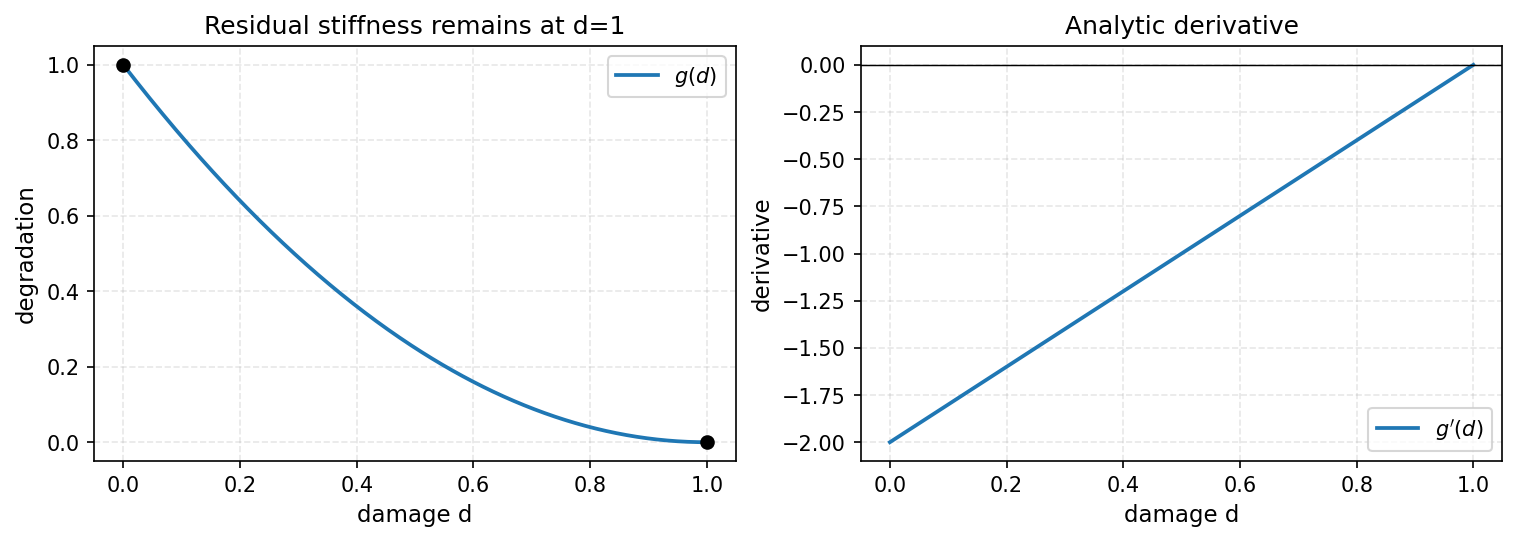

In [4]:
d_plot = torch.linspace(0.0, 1.0, 400, dtype=torch.float64)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].plot(d_plot, material.degradation(d_plot), label=r"$g(d)$")
axes[0].scatter([0, 1], endpoints, color="black", zorder=3)
axes[0].set(xlabel="damage d", ylabel="degradation", title="Residual stiffness remains at d=1")
axes[0].legend()
axes[1].plot(d_plot, gp_analytic(d_plot), label=r"$g'(d)$")
axes[1].axhline(0, color="black", lw=0.7)
axes[1].set(xlabel="damage d", ylabel="derivative", title="Analytic derivative")
axes[1].legend()
fig.savefig(assets_dir() / "degradation_autograd.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Standard degradation function and its analytic derivative over damage from zero to one.")
plt.close(fig)


**Why this matters.** Automatic differentiation follows the tensor
operations connected to a scalar loss. For a complete solver, trace
that connection through the boundary conditions, equilibrium solve,
history update and active constraints. The next exercise develops
this parameter-to-observation chain for an elastic bar.


## Key takeaways

- The normalised quadratic law retains stiffness $g(1)=\eta$ in the fully damaged state.
- Autograd computes the derivative of the tensor operations connecting the selected input to the output.
- A centred difference differentiates this quadratic exactly in exact arithmetic; floating-point roundoff matters as the spacing shrinks.
- A derivative of the material law is one contribution to the coupled solver sensitivity.

## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Evaluate the law, its slope, and its curvature

For

$$
g(d)=(1-\eta)(1-d)^2+\eta,
\qquad \eta=10^{-7},
$$

compute $g(0)$, $g(1)$, $g(0.25)$, $g'(0.25)$, and $g''(d)$. State whether $g$ is decreasing and whether it is convex on $0\le d\le1$.

### Exercise 2: Explore finite-difference spacing for a quadratic law

1. Derive the centred-difference formula using Taylor expansions. What happens to its truncation term for this quadratic degradation law?
2. Evaluate the existing `g_analytic` and `gp_analytic` at $d=0.25$ using spacings from $10^{-2}$ to $10^{-16}$. Plot the absolute derivative error against spacing and explain the small-spacing behaviour.
3. For a scalar loss depending on many parameters, compare the work of centred finite differences with reverse-mode differentiation.